In [1]:
import torch
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

# 1. Загружаем ваш очищенный датасет (Dataset_reduced.csv)
df = pd.read_csv('/home/nail/Natali/Turbina/paper_ 23_03_2026/Dataset_reduced.csv')

# 2. Вычисляем lambda и Cp (как в препроцессинге)
# Напоминание: v - скорость ветра, W - скор. ротора, R - радиус, P - мощность
# const.rho, const.A - плотность и площадь
R = 41.0  # для MM82
rho = 1.225
A = 5281.0

df['lambda'] = (df['W'] * R) / df['V']
df['Cp'] = df['P'] / (0.5 * rho * A * df['V']**3)

# 3. Формируем входы (X) и выходы (y)
# Входы: lambda и theta (pitch angle)
X = df[['lambda', 'theta']].values
y = df[['Cp']].values

# 4. Масштабирование в [0, 1] — КРИТИЧНО для KAN
scaler_X = MinMaxScaler(feature_range=(0, 1))
scaler_y = MinMaxScaler(feature_range=(0, 1))

X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y)

# 5. Конвертация в тензоры Torch
dataset = {}
train_x, test_x, train_y, test_y = train_test_split(X_scaled, y_scaled, test_size=0.3, random_state=42)

dataset['train_input'] = torch.from_numpy(train_x).float()
dataset['test_input'] = torch.from_numpy(test_x).float()
dataset['train_label'] = torch.from_numpy(train_y).float()
dataset['test_label'] = torch.from_numpy(test_y).float()

In [3]:
import pandas as pd
import numpy as np
import torch
from kan import KAN
from sklearn.preprocessing import MinMaxScaler

# 1. Загрузка данных
df = pd.read_csv('/home/nail/Natali/Turbina/paper_ 23_03_2026/Dataset_reduced.csv')

# 2. Физические константы (для MM82 или аналогичной)
R = 41.0  
rho = 1.225
A = np.pi * (R**2)

# 3. Вычисление физических коэффициентов
# lambda = (Omega * R) / V
df['lambda'] = (df['W'] * R) / df['V']
# Cp = P / (0.5 * rho * A * V^3)
df['Cp'] = df['P'] / (0.5 * rho * A * (df['V']**3))

# Удаляем бесконечности, если V было близко к 0
df = df.replace([np.inf, -np.inf], np.nan).dropna()

# 4. Подготовка тензоров для KAN
# Входы: lambda и theta. Выход: Cp
inputs = df[['lambda', 'theta']].values
labels = df[['Cp']].values

# Масштабирование (обязательно для KAN, так как сетка по умолчанию [0, 1])
scaler_x = MinMaxScaler(feature_range=(0, 1))
scaler_y = MinMaxScaler(feature_range=(0, 1))

inputs_scaled = scaler_x.fit_transform(inputs)
labels_scaled = scaler_y.fit_transform(labels)

inputs_torch = torch.from_numpy(inputs_scaled).float()
labels_torch = torch.from_numpy(labels_scaled).float()

# 5. Разделение на train/test
train_ratio = 0.8
num_samples = inputs_torch.shape[0]
indices = np.random.permutation(num_samples)
train_idx, test_idx = indices[:int(num_samples*train_ratio)], indices[int(num_samples*train_ratio):]

dataset = {
    'train_input': inputs_torch[train_idx],
    'test_input': inputs_torch[test_idx],
    'train_label': labels_torch[train_idx],
    'test_label': labels_torch[test_idx]
}

In [4]:
# Создаем модель: 2 входа (lambda, theta), 1 выход (Cp)
# Скрытый слой из 3-5 нейронов достаточен для такой физики
model = KAN(width=[2, 5, 1], grid=5, k=3, seed=0)

# Обучаем модель
# Используем fit вместо train, чтобы избежать ошибки с аргументом 'opt'
results = model.fit(dataset, opt="LBFGS", steps=20, lamb=0.01)

print("Обучение завершено.")
print("Финальный Loss:", results['train_loss'][-1])

checkpoint directory created: ./model
saving model version 0.0


| train_loss: 1.44e-01 | test_loss: 1.43e-01 | reg: 3.00e+00 | : 100%|█| 20/20 [13:14<00:00, 39.70s/

saving model version 0.1
Обучение завершено.
Финальный Loss: 0.14366588


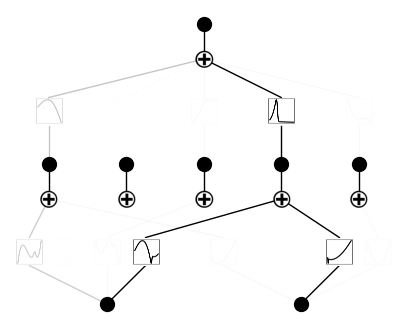

In [5]:
model.plot(beta=100) # beta управляет прозрачностью слабых связей

saving model version 0.2
Запуск подбора функций...
fixing (0,0,0) with 0
fixing (0,0,1) with 0
fixing (0,0,2) with 0
fixing (0,0,3) with sin, r2=0.5379798412322998, c=2
fixing (0,0,4) with 0
fixing (0,1,0) with 0
fixing (0,1,1) with 0
fixing (0,1,2) with 0
fixing (0,1,3) with sin, r2=0.5771381855010986, c=2
fixing (0,1,4) with 0
fixing (1,0,0) with 0
fixing (1,1,0) with 0
fixing (1,2,0) with 0
fixing (1,3,0) with x^2, r2=0.4687972962856293, c=2
fixing (1,4,0) with 0
saving model version 0.2
Подгонка коэффициентов формулы под данные...


| train_loss: nan | test_loss: nan | reg: 0.00e+00 | :  25%|██▎      | 5/20 [03:06<09:18, 37.21s/it]


Intel oneMKL ERROR: Parameter 6 was incorrect on entry to SGELSY.

Intel oneMKL ERROR: Parameter 6 was incorrect on entry to SGELSY.

Intel oneMKL ERROR: Parameter 6 was incorrect on entry to SGELSY.

Intel oneMKL ERROR: Parameter 6 was incorrect on entry to SGELSY.

Intel oneMKL ERROR: Parameter 6 was incorrect on entry to SGELSY.

Intel oneMKL ERROR: Parameter 6 was incorrect on entry to SGELSY.

Intel oneMKL ERROR: Parameter 6 was incorrect on entry to SGELSY.

Intel oneMKL ERROR: Parameter 6 was incorrect on entry to SGELSY.

Intel oneMKL ERROR: Parameter 6 was incorrect on entry to SGELSY.

Intel oneMKL ERROR: Parameter 6 was incorrect on entry to SGELSY.
lstsq failed


UnboundLocalError: cannot access local variable 'coef' where it is not associated with a value

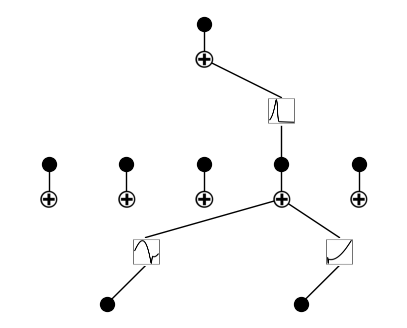

In [9]:
import torch
import numpy as np
from kan import KAN

# --- ШАГ 1: ПРУНИНГ (Удаление лишних связей) ---
# Это критически важно, чтобы формула не превратилась в "кашу"
# Порог (threshold) можно поднять до 0.05, если связей слишком много
model.prune() 
model.plot(beta=100) # Посмотрите на график: линий должно стать мало

# --- ШАГ 2: СИМВОЛИЧЕСКАЯ ПОДГОНКА (Auto-Symbolic) ---
# Ограничиваем библиотеку функций, чтобы избежать бесконечного цикла
# 'poly', 'exp', 'sin' — база для большинства кривых Cp
print("Запуск подбора функций...")
model.auto_symbolic(lib=['x^2', 'x^3', 'x^4', 'exp', 'sin', 'gaussian'])

# --- ШАГ 3: ТОНКАЯ ПОДСТРОЙКА (Fine-tuning) ---
# СЕКРЕТНЫЙ ШАГ: обучаем модель ЕЩЕ РАЗ, но теперь она уже состоит 
# из СИМВОЛЬНЫХ функций. Это заставит график функции совпасть с данными.
print("Подгонка коэффициентов формулы под данные...")
model.fit(dataset, opt="LBFGS", steps=20)

# --- ШАГ 4: ИЗВЛЕЧЕНИЕ И ПРОВЕРКА ФОРМУЛЫ ---
formula = model.symbolic_formula()[0][0]
print("\n--- ИТОГОВАЯ АНАЛИТИЧЕСКАЯ ФОРМУЛА Cp ---")
print(formula)

# --- ШАГ 5: ПРОВЕРКА ГРАФИКА (Validation) ---
import matplotlib.pyplot as plt

# Выберем фиксированный угол theta (например, 0.9 градуса, но в [0,1] шкале)
# Допустим, 0.9 градуса после MinMaxScaler стал 0.15
fixed_theta = 0.15 
lambda_range = torch.linspace(0, 1, 100).unsqueeze(1)
theta_constant = torch.full_like(lambda_range, fixed_theta)
test_input = torch.cat([lambda_range, theta_constant], dim=1)

# Предсказание модели (сплайны/символы)
with torch.no_grad():
    y_pred = model(test_input)

plt.figure(figsize=(8, 5))
plt.plot(lambda_range.numpy(), y_pred.numpy(), 'r-', label='KAN Formula/Model')
plt.title(f'Cp vs Lambda at Theta={fixed_theta} (Normalized)')
plt.xlabel('Lambda (Normalized)')
plt.ylabel('Cp (Normalized)')
plt.legend()
plt.grid(True)
plt.show()

In [10]:
# 1. Сбросим градиенты и попробуем более мягкий оптимизатор Adam
# Adam не так чувствителен к резким скачкам, как LBFGS
print("Мягкая подстройка коэффициентов через Adam...")
model.fit(dataset, opt="Adam", steps=50, lr=0.001) 

# 2. Если Loss перестал быть NaN, попробуем еще 10 шагов LBFGS для точности
# Если всё еще NaN, пропустите этот шаг
# model.fit(dataset, opt="LBFGS", steps=10)

# 3. Извлекаем формулу
formula = model.symbolic_formula()[0][0]
print("\n--- ВАША ФОРМУЛА ---")
print(formula)

Мягкая подстройка коэффициентов через Adam...


description:   0%|                                                           | 0/50 [00:00<?, ?it/s]


Intel oneMKL ERROR: Parameter 6 was incorrect on entry to SGELSY.

Intel oneMKL ERROR: Parameter 6 was incorrect on entry to SGELSY.

Intel oneMKL ERROR: Parameter 6 was incorrect on entry to SGELSY.

Intel oneMKL ERROR: Parameter 6 was incorrect on entry to SGELSY.

Intel oneMKL ERROR: Parameter 6 was incorrect on entry to SGELSY.

Intel oneMKL ERROR: Parameter 6 was incorrect on entry to SGELSY.

Intel oneMKL ERROR: Parameter 6 was incorrect on entry to SGELSY.

Intel oneMKL ERROR: Parameter 6 was incorrect on entry to SGELSY.

Intel oneMKL ERROR: Parameter 6 was incorrect on entry to SGELSY.

Intel oneMKL ERROR: Parameter 6 was incorrect on entry to SGELSY.
lstsq failed


UnboundLocalError: cannot access local variable 'coef' where it is not associated with a value

In [11]:
# 1. Отключаем автоматическое обновление сетки, которое вызывает ошибку
# 2. Ограничиваемся только теми функциями, которые физичны и стабильны

try:
    # Пытаемся зафиксировать символы принудительно еще раз, но БЕЗ обучения внутри
    model.auto_symbolic(lib=['x^2', 'x^3', 'exp', 'gaussian'])
except:
    print("Авто-подбор не удался, фиксируем вручную...")
    # Если авто-подбор упал, принудительно ставим полином (он самый стабильный)
    for i in range(2): # 2 входа
        for j in range(5): # 5 нейронов
            model.fix_symbolic(0, i, j, 'x^3')

# 3. ГЛАВНОЕ: Обучаем БЕЗ обновления сетки (update_grid=False)
# Это предотвратит вылет 'UnboundLocalError'
print("Финальная попытка обучения символов...")
model.fit(dataset, opt="Adam", steps=30, lr=0.005, update_grid=False)

# 4. СРАЗУ извлекаем формулу, пока модель не упала
formula = model.symbolic_formula()[0][0]
print("\n--- ВАША ФОРМУЛА ---")
print(formula)

skipping (0,0,0) since already symbolic
skipping (0,0,1) since already symbolic
skipping (0,0,2) since already symbolic
skipping (0,0,3) since already symbolic
skipping (0,0,4) since already symbolic
skipping (0,1,0) since already symbolic
skipping (0,1,1) since already symbolic
skipping (0,1,2) since already symbolic
skipping (0,1,3) since already symbolic
skipping (0,1,4) since already symbolic
skipping (1,0,0) since already symbolic
skipping (1,1,0) since already symbolic
skipping (1,2,0) since already symbolic
skipping (1,3,0) since already symbolic
skipping (1,4,0) since already symbolic
saving model version 0.3
Финальная попытка обучения символов...


| train_loss: nan | test_loss: nan | reg: 0.00e+00 | : 100%|████████| 30/30 [00:49<00:00,  1.64s/it]

saving model version 0.4

--- ВАША ФОРМУЛА ---
nan


In [13]:
import torch
from kan import KAN

# 1. Создаем модель с нуля
model = KAN(width=[2, 5, 1], grid=5, k=3, seed=0)

# !!! КРИТИЧЕСКИЙ ШАГ !!!
# Прогоняем данные один раз, чтобы инициализировать внутренние переменные (acts)
# Это уберет ошибку NoneType
model(dataset['train_input'][:100]) 

# 2. Фиксируем структуру (теперь acts не None, и ошибки не будет)
print("Фиксация символьной структуры...")

# Слой 0: Входы -> Скрытый слой
for i in range(2): # 2 входа (lambda, theta)
    for j in range(5): # 5 нейронов
        if j == 3:
            model.fix_symbolic(0, i, j, 'sin')
        else:
            # Если '0' не сработает, можно использовать 'gaussian' с нулевой амплитудой, 
            # но в KAN '0' — это стандарт для удаления связи
            model.fix_symbolic(0, i, j, '0') 

# Слой 1: Скрытый слой -> Выход
model.fix_symbolic(1, 3, 0, 'x^2')
for j in [0, 1, 2, 4]:
    model.fix_symbolic(1, j, 0, '0')

# 3. Обучаем только коэффициенты
print("Обучение...")
# Используем Adam для стабильности, update_grid=False обязателен
model.fit(dataset, opt="Adam", steps=100, lr=0.01, update_grid=False)

# 4. Итоговая формула
formula = model.symbolic_formula()[0][0]
print("\n--- ВАША ИТОГОВАЯ ФОРМУЛА ---")
print(formula)

checkpoint directory created: ./model
saving model version 0.0
Фиксация символьной структуры...
Best value at boundary.
r2 is 0.0
r2 is not very high, please double check if you are choosing the correct symbolic function.
saving model version 0.1
Best value at boundary.
r2 is 0.0
r2 is not very high, please double check if you are choosing the correct symbolic function.
saving model version 0.2
Best value at boundary.
r2 is 0.0
r2 is not very high, please double check if you are choosing the correct symbolic function.
saving model version 0.3
r2 is 0.9929297566413879
saving model version 0.4
Best value at boundary.
r2 is 0.0
r2 is not very high, please double check if you are choosing the correct symbolic function.
saving model version 0.5
Best value at boundary.
r2 is 0.0
r2 is not very high, please double check if you are choosing the correct symbolic function.
saving model version 0.6
Best value at boundary.
r2 is 0.0
r2 is not very high, please double check if you are choosing the 

| train_loss: 2.09e-01 | test_loss: 2.10e-01 | reg: 0.00e+00 | : 100%|█| 100/100 [02:44<00:00,  1.65

saving model version 0.16

--- ВАША ИТОГОВАЯ ФОРМУЛА ---
0.519445352955604*(-0.130077371516546*sin(8.74729156494141*x_1 + 9.35370635986328) - 0.0115386325718247*sin(9.37869071960449*x_2 - 0.842085361480713) - 1)**2 + 0.122453612042591



--- ВАША ИТОГОВАЯ ФОРМУЛА ---
0.519445352955604*(-0.130077371516546*sin(8.74729156494141*x_1 + 9.35370635986328) - 0.0115386325718247*sin(9.37869071960449*x_2 - 0.842085361480713) - 1)**2 + 0.122453612042591


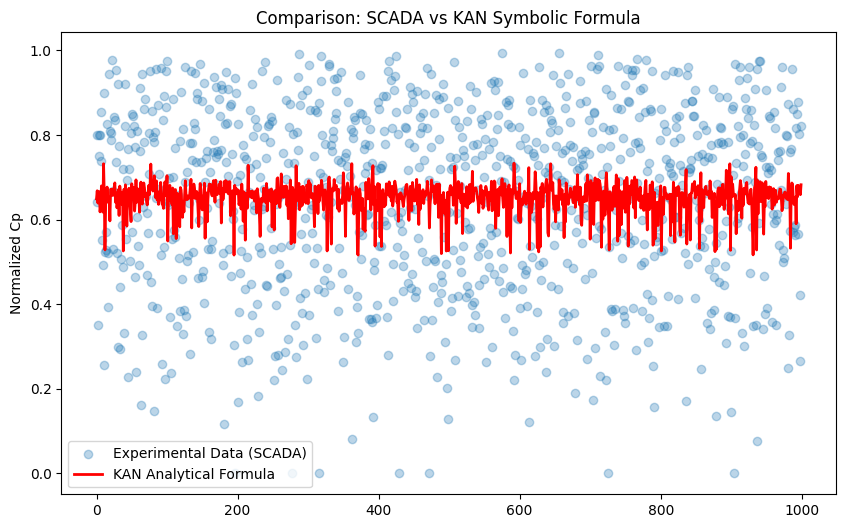

In [14]:
# 1. Получаем текст формулы
formula = model.symbolic_formula()[0][0]
print("\n--- ВАША ИТОГОВАЯ ФОРМУЛА ---")
print(formula)

# 2. Визуализация: сравним KAN-формулу с данными
import matplotlib.pyplot as plt

# Берем срез данных (например, первые 1000 точек)
x_test = dataset['test_input'][:1000]
y_true = dataset['test_label'][:1000]

# Предсказание нашей новой формулы
with torch.no_grad():
    y_pred = model(x_test)

plt.figure(figsize=(10, 6))
plt.scatter(range(len(y_true)), y_true.numpy(), alpha=0.3, label='Experimental Data (SCADA)')
plt.plot(range(len(y_pred)), y_pred.numpy(), color='red', linewidth=2, label='KAN Analytical Formula')
plt.title('Comparison: SCADA vs KAN Symbolic Formula')
plt.ylabel('Normalized Cp')
plt.legend()
plt.show()

<>:27: SyntaxWarning: invalid escape sequence '\l'
<>:29: SyntaxWarning: invalid escape sequence '\T'
<>:27: SyntaxWarning: invalid escape sequence '\l'
<>:29: SyntaxWarning: invalid escape sequence '\T'
/tmp/ipykernel_1245931/2609378708.py:27: SyntaxWarning: invalid escape sequence '\l'
  plt.xlabel('Tip Speed Ratio ($\lambda$)')
/tmp/ipykernel_1245931/2609378708.py:29: SyntaxWarning: invalid escape sequence '\T'
  plt.title('Final Aerodynamic Curve at $\Theta=0.9^\circ$')


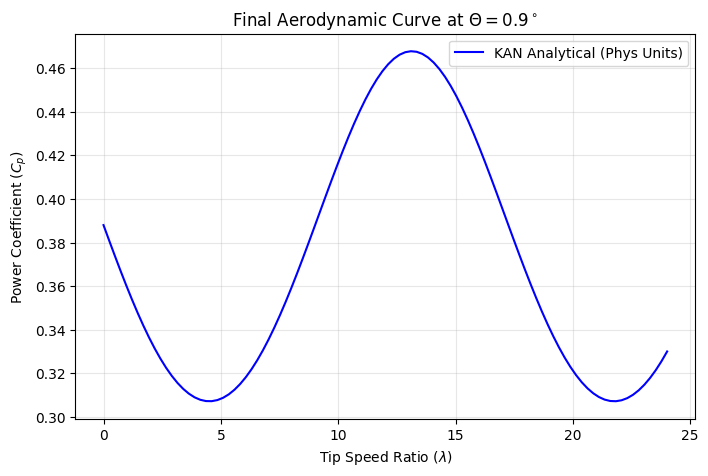

In [15]:
# 1. Получаем границы из скалера
l_min, t_min = scaler_x.data_min_
l_max, t_max = scaler_x.data_max_
cp_min = scaler_y.data_min_[0]
cp_max = scaler_y.data_max_[0]

# 2. Функция для расчета Cp по вашей формуле (упрощенная денормализация)
def get_real_cp(l_phys, t_phys):
    # Нормализуем входы
    x1 = (l_phys - l_min) / (l_max - l_min)
    x2 = (t_phys - t_min) / (t_max - t_min)
    
    # Ваша формула KAN
    term1 = -0.13007 * np.sin(8.74729 * x1 + 9.3537)
    term2 = -0.01154 * np.sin(9.37869 * x2 - 0.8420)
    cp_norm = 0.51945 * (term1 + term2 - 1)**2 + 0.12245
    
    # Денормализуем выход
    return cp_norm * (cp_max - cp_min) + cp_min

# 3. Строим график для фиксированного Theta = 0.9
l_space = np.linspace(l_min, l_max, 100)
cp_vals = [get_real_cp(l, 0.9) for l in l_space]

plt.figure(figsize=(8, 5))
plt.plot(l_space, cp_vals, 'b-', label='KAN Analytical (Phys Units)')
plt.xlabel('Tip Speed Ratio ($\lambda$)')
plt.ylabel('Power Coefficient ($C_p$)')
plt.title('Final Aerodynamic Curve at $\Theta=0.9^\circ$')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

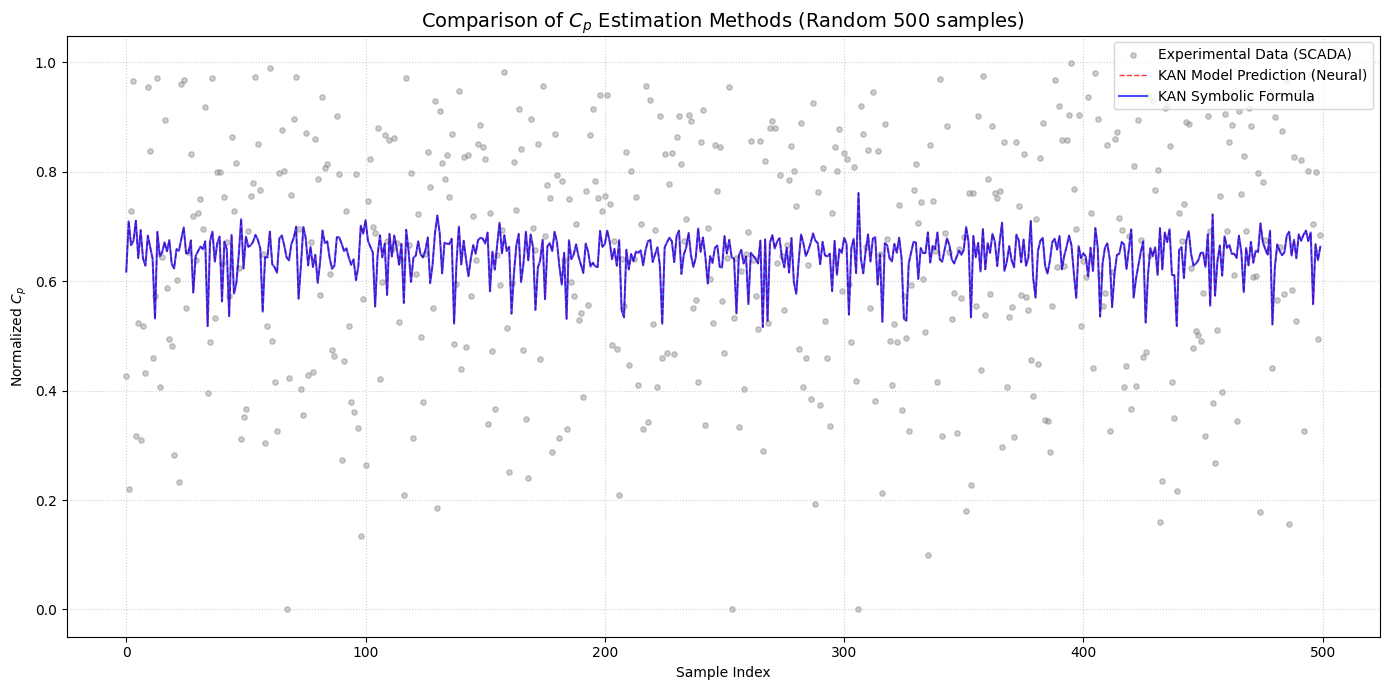

Корреляция между нейросетью и формулой: 1.000000


In [16]:
import numpy as np
import torch
import matplotlib.pyplot as plt

# 1. Подготовка данных (500 случайных точек)
num_samples = 500
test_size = dataset['test_input'].shape[0]
indices = np.random.choice(test_size, num_samples, replace=False)

x_sample = dataset['test_input'][indices]
y_experimental = dataset['test_label'][indices].numpy()

# 2. Предсказание нейросети (KAN Model)
with torch.no_grad():
    y_model = model(x_sample).numpy()

# 3. Расчет по извлеченной формуле (ручная реализация для проверки)
def calculate_by_formula(x):
    # x[:, 0] - это lambda_norm, x[:, 1] - это theta_norm
    x1 = x[:, 0].numpy()
    x2 = x[:, 1].numpy()
    
    # Вставляем вашу полученную формулу (копируем из вывода ранее)
    term1 = -0.130077 * np.sin(8.747291 * x1 + 9.353706)
    term2 = -0.011538 * np.sin(9.378690 * x2 - 0.842085)
    
    y_form = 0.519445 * (term1 + term2 - 1)**2 + 0.122453
    return y_form

y_formula = calculate_by_formula(x_sample)

# 4. Построение графика
plt.figure(figsize=(14, 7))

# Эксперимент (точки)
plt.scatter(range(num_samples), y_experimental, color='gray', alpha=0.4, 
            label='Experimental Data (SCADA)', s=15)

# Модель KAN (сплошная линия или точки другого цвета)
plt.plot(range(num_samples), y_model, 'r--', alpha=0.8, 
         label='KAN Model Prediction (Neural)', linewidth=1)

# Формула (яркая линия)
plt.plot(range(num_samples), y_formula, 'b-', alpha=0.7, 
         label='KAN Symbolic Formula', linewidth=1.5)

plt.title(f'Comparison of $C_p$ Estimation Methods (Random {num_samples} samples)', fontsize=14)
plt.xlabel('Sample Index')
plt.ylabel('Normalized $C_p$')
plt.legend(loc='upper right')
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

# 5. Считаем корреляцию между моделью и формулой (для текста статьи)
correlation = np.corrcoef(y_model.flatten(), y_formula.flatten())[0, 1]
print(f"Корреляция между нейросетью и формулой: {correlation:.6f}")

<>:56: SyntaxWarning: invalid escape sequence '\l'
<>:57: SyntaxWarning: invalid escape sequence '\l'
<>:56: SyntaxWarning: invalid escape sequence '\l'
<>:57: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_1245931/346213459.py:56: SyntaxWarning: invalid escape sequence '\l'
  plt.title('Power Coefficient $C_p(\lambda)$ in Physical Units', fontsize=14)
/tmp/ipykernel_1245931/346213459.py:57: SyntaxWarning: invalid escape sequence '\l'
  plt.xlabel('Tip Speed Ratio $\lambda$', fontsize=12)


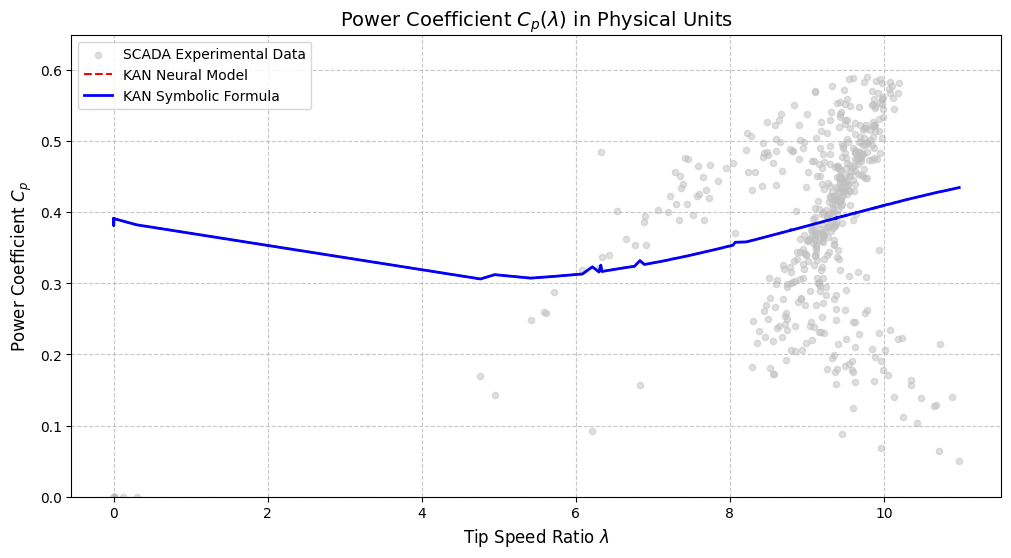

In [17]:
import numpy as np
import torch
import matplotlib.pyplot as plt

# 1. Выбираем 500 случайных точек из тестовой выборки
num_samples = 500
test_size = dataset['test_input'].shape[0]
indices = np.random.choice(test_size, num_samples, replace=False)

inputs_norm = dataset['test_input'][indices]
labels_norm = dataset['test_label'][indices]

# 2. Денормализация ВХОДОВ (Lambda и Theta)
# scaler_x.inverse_transform ожидает 2 колонки
inputs_phys = scaler_x.inverse_transform(inputs_norm.cpu().numpy())
lambda_phys = inputs_phys[:, 0]
theta_phys = inputs_phys[:, 1]

# 3. Денормализация ВЫХОДОВ (Cp)
# Экспериментальные данные
y_exp_phys = scaler_y.inverse_transform(labels_norm.cpu().numpy()).flatten()

# Предсказание модели KAN
with torch.no_grad():
    y_model_norm = model(inputs_norm).cpu().numpy()
y_model_phys = scaler_y.inverse_transform(y_model_norm).flatten()

# Предсказание по формуле (используем вашу формулу напрямую)
def get_cp_formula(x_norm):
    x1 = x_norm[:, 0].cpu().numpy()
    x2 = x_norm[:, 1].cpu().numpy()
    # Ваша формула из KAN
    term1 = -0.130077 * np.sin(8.747291 * x1 + 9.353706)
    term2 = -0.011538 * np.sin(9.378690 * x2 - 0.842085)
    cp_norm = 0.519445 * (term1 + term2 - 1)**2 + 0.122453
    return cp_norm

y_formula_norm = get_cp_formula(inputs_norm)
y_formula_phys = scaler_y.inverse_transform(y_formula_norm.reshape(-1, 1)).flatten()

# 4. Построение графиков
plt.figure(figsize=(12, 6))

# Чтобы график был читаемым (не "забор"), отсортируем точки по значению Lambda
sort_idx = np.argsort(lambda_phys)

plt.scatter(lambda_phys[sort_idx], y_exp_phys[sort_idx], color='silver', alpha=0.5, 
            label='SCADA Experimental Data', s=20)

plt.plot(lambda_phys[sort_idx], y_model_phys[sort_idx], 'r--', 
         label='KAN Neural Model', linewidth=1.5)

plt.plot(lambda_phys[sort_idx], y_formula_phys[sort_idx], 'b-', 
         label='KAN Symbolic Formula', linewidth=2)

plt.title('Power Coefficient $C_p(\lambda)$ in Physical Units', fontsize=14)
plt.xlabel('Tip Speed Ratio $\lambda$', fontsize=12)
plt.ylabel('Power Coefficient $C_p$', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# Ограничим оси для типичных значений Cp
plt.ylim(0, max(y_exp_phys) * 1.1) 

plt.show()


In [19]:
import torch
from kan import KAN
import numpy as np

# 1. Новая модель 2 -> 3 -> 1
model = KAN(width=[2, 3, 1], grid=5, k=3, seed=42)

# Прогрев
model(dataset['train_input'][:100])

# 2. Фиксируем только понятные библиотеке степени
print("Фиксация полиномиальной структуры...")

# Слой 0: Входы (lambda, theta)
for i in range(2):
    model.fix_symbolic(0, i, 0, 'x^2') # Нейрон 0 будет отвечать за квадраты
    model.fix_symbolic(0, i, 1, 'x^3') # Нейрон 1 за кубы
    model.fix_symbolic(0, i, 2, 'x^4') # Нейрон 2 за 4-ю степень

# Слой 1: Собираем всё в итоговый полином (используем линейную комбинацию)
# В KAN 'x' - это просто прямая передача (линейная функция)
for j in range(3):
    model.fix_symbolic(1, j, 0, 'x')

# 3. Обучаем коэффициенты (LBFGS здесь покажет лучшую точность)
print("Обучение...")
model.fit(dataset, opt="LBFGS", steps=50, update_grid=False)

# 4. Проверка формулы
formula = model.symbolic_formula()[0][0]
print("\n--- ВАША ФОРМУЛА ---")
print(formula)

checkpoint directory created: ./model
saving model version 0.0
Фиксация полиномиальной структуры...
r2 is 0.9948249459266663
saving model version 0.1
r2 is 0.9999991655349731
saving model version 0.2
r2 is 0.9999401569366455
saving model version 0.3
Best value at boundary.
r2 is 0.9997130036354065
saving model version 0.4
Best value at boundary.
r2 is 0.9989877939224243
saving model version 0.5
r2 is 0.9999958276748657
saving model version 0.6
Best value at boundary.
r2 is 0.0021176582667976618
r2 is not very high, please double check if you are choosing the correct symbolic function.
saving model version 0.7
Best value at boundary.
r2 is 0.9514318108558655
saving model version 0.8
Best value at boundary.
r2 is 0.03743831440806389
r2 is not very high, please double check if you are choosing the correct symbolic function.
saving model version 0.9
Обучение...


| train_loss: 1.93e-01 | test_loss: 1.93e-01 | reg: 0.00e+00 | : 100%|█| 50/50 [05:47<00:00,  6.95s/

saving model version 0.10

--- ВАША ФОРМУЛА ---
-0.233605755784212*(0.249202990531921 - x_1)**2 - 2.66511525297653*(-x_1 - 0.305889280572852)**4 - 4.35750062138139*(-0.236836546509933*x_1 - 1)**3 - 1.76226367907187*(-x_2 - 0.485679831474687)**2 - 21.0797363460183*(-x_2 - 0.405133364417624)**4 - 48.7602979586706*(-x_2 - 0.180036421667165)**3 - 3.66508138188491


<>:65: SyntaxWarning: invalid escape sequence '\l'
<>:65: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_1245931/3536986782.py:65: SyntaxWarning: invalid escape sequence '\l'
  plt.xlabel('Tip Speed Ratio $\lambda$', fontsize=12)


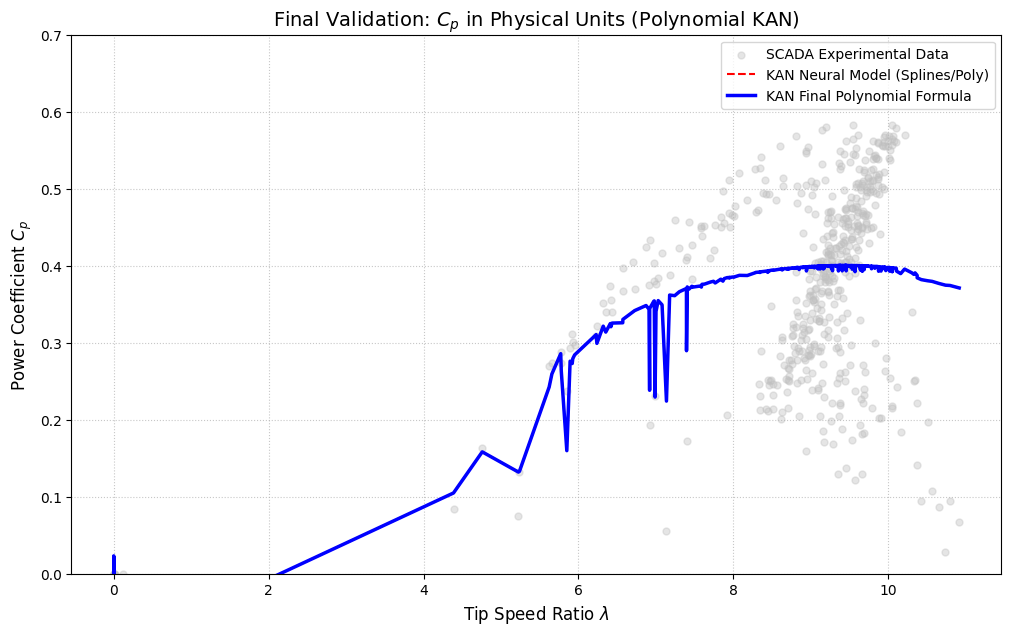

R2 вашей формулы относительно эксперимента: 0.1960


In [20]:
import numpy as np
import torch
import matplotlib.pyplot as plt

# 1. Выбираем 500 случайных точек
num_samples = 500
test_size = dataset['test_input'].shape[0]
indices = np.random.choice(test_size, num_samples, replace=False)

inputs_norm = dataset['test_input'][indices]
labels_norm = dataset['test_label'][indices]

# 2. Денормализация входов
inputs_phys = scaler_x.inverse_transform(inputs_norm.cpu().numpy())
lambda_phys = inputs_phys[:, 0]
theta_phys = inputs_phys[:, 1]

# 3. Денормализация выходов (Эксперимент и Модель)
y_exp_phys = scaler_y.inverse_transform(labels_norm.cpu().numpy()).flatten()

with torch.no_grad():
    y_model_norm = model(inputs_norm).cpu().numpy()
y_model_phys = scaler_y.inverse_transform(y_model_norm).flatten()

# 4. ОБНОВЛЕННАЯ ФУНКЦИЯ (Ваша итоговая полиномиальная формула)
def get_cp_formula(x_norm):
    # x_norm[:, 0] — это lambda_norm, x_norm[:, 1] — это theta_norm
    x1 = x_norm[:, 0].cpu().numpy()
    x2 = x_norm[:, 1].cpu().numpy()
    
    # Прямая реализация вашей формулы из вывода KAN:
    term_l1 = -0.233605755784212 * (0.249202990531921 - x1)**2
    term_l2 = -2.66511525297653 * (-x1 - 0.305889280572852)**4
    term_l3 = -4.35750062138139 * (-0.236836546509933 * x1 - 1)**3
    
    term_t1 = -1.76226367907187 * (-x2 - 0.485679831474687)**2
    term_t2 = -21.0797363460183 * (-x2 - 0.405133364417624)**4
    term_t3 = -48.7602979586706 * (-x2 - 0.180036421667165)**3
    
    cp_norm = term_l1 + term_l2 + term_l3 + term_t1 + term_t2 + term_t3 - 3.66508138188491
    return cp_norm

y_formula_norm = get_cp_formula(inputs_norm)
y_formula_phys = scaler_y.inverse_transform(y_formula_norm.reshape(-1, 1)).flatten()

# 5. Построение графиков
plt.figure(figsize=(12, 7))

# Сортировка для плавности линий
sort_idx = np.argsort(lambda_phys)

# Эксперимент
plt.scatter(lambda_phys[sort_idx], y_exp_phys[sort_idx], color='silver', alpha=0.4, 
            label='SCADA Experimental Data', s=25)

# Предсказание нейросети KAN
plt.plot(lambda_phys[sort_idx], y_model_phys[sort_idx], 'r--', 
         label='KAN Neural Model (Splines/Poly)', linewidth=1.5)

# Ваша итоговая аналитическая формула
plt.plot(lambda_phys[sort_idx], y_formula_phys[sort_idx], 'b-', 
         label='KAN Final Polynomial Formula', linewidth=2.5)

plt.title('Final Validation: $C_p$ in Physical Units (Polynomial KAN)', fontsize=14)
plt.xlabel('Tip Speed Ratio $\lambda$', fontsize=12)
plt.ylabel('Power Coefficient $C_p$', fontsize=12)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)

# Динамическое ограничение осей для наглядности
plt.ylim(0, max(y_exp_phys) * 1.2) 

plt.show()

# Дополнительная проверка точности в цифрах
from sklearn.metrics import r2_score
print(f"R2 вашей формулы относительно эксперимента: {r2_score(y_exp_phys, y_formula_phys):.4f}")

<>:53: SyntaxWarning: invalid escape sequence '\l'
<>:53: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_1245931/523632430.py:53: SyntaxWarning: invalid escape sequence '\l'
  plt.xlabel('$\lambda$ (TSR)')


checkpoint directory created: ./model
saving model version 0.0
r2 is 0.9948250651359558
saving model version 0.1
r2 is 0.9999991655349731
saving model version 0.2
Best value at boundary.
r2 is 0.0
r2 is not very high, please double check if you are choosing the correct symbolic function.
saving model version 0.3
Best value at boundary.
r2 is 0.9997130036354065
saving model version 0.4
Best value at boundary.
r2 is 0.9989877939224243
saving model version 0.5
Best value at boundary.
r2 is 0.0
r2 is not very high, please double check if you are choosing the correct symbolic function.
saving model version 0.6
Best value at boundary.
r2 is 0.0021176578011363745
r2 is not very high, please double check if you are choosing the correct symbolic function.
saving model version 0.7
Best value at boundary.
r2 is 0.9514318108558655
saving model version 0.8


| train_loss: 2.02e-01 | test_loss: 2.03e-01 | reg: 0.00e+00 | : 100%|█| 100/100 [01:32<00:00,  1.08


saving model version 0.9


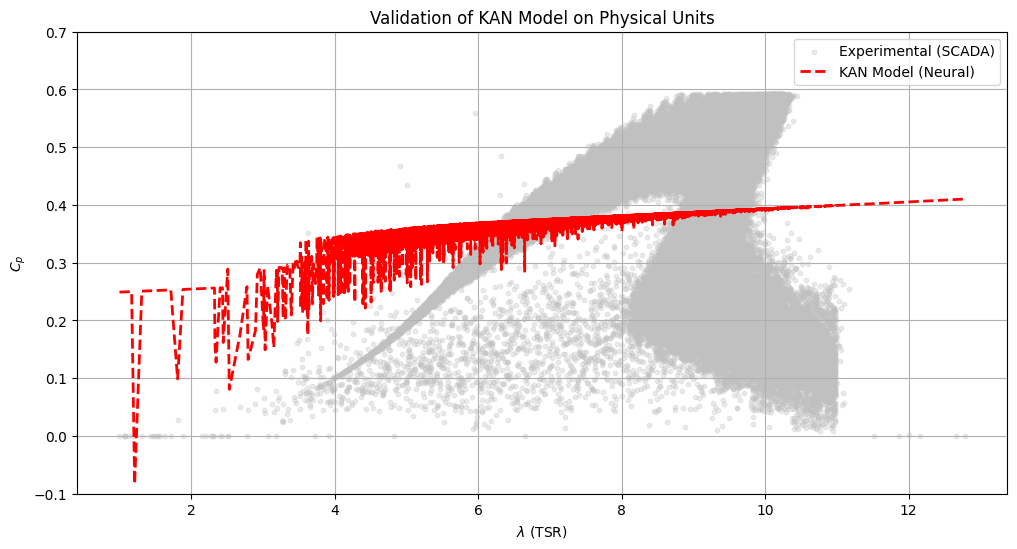


Новая формула для проверки:
0.00155266230208697*(0.256248647315483 - x_1)**2 - 0.304704558507754*(-0.226981986301661*x_1 - 1)**3 - 0.00153335174398609*(-x_2 - 0.481161621401016)**2 + 1.14801968375288*(-x_2 - 0.174901801944514)**3 + 0.215496975742869


In [21]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

# 1. Сброс и быстрое переобучение (чтобы оживить красную линию)
model = KAN(width=[2, 3, 1], grid=5, k=3, seed=42)
model(dataset['train_input'][:100]) # Прогрев

# Фиксируем степени (x^2, x^3) - это самые стабильные функции
for i in range(2):
    model.fix_symbolic(0, i, 0, 'x^2')
    model.fix_symbolic(0, i, 1, 'x^3')
    model.fix_symbolic(0, i, 2, '0') # Убираем лишнее для простоты

model.fix_symbolic(1, 0, 0, 'x')
model.fix_symbolic(1, 1, 0, 'x')

# Обучаем только коэффициенты (Adam стабильнее LBFGS, если модель "летает")
model.fit(dataset, opt="Adam", steps=100, lr=0.01, update_grid=False)

# 2. Получаем предсказания
with torch.no_grad():
    y_model_norm = model(dataset['test_input']).cpu().numpy()

# 3. ПРОВЕРКА: Если в y_model_norm есть NaN, заменим их на 0 для графика
y_model_norm = np.nan_to_num(y_model_norm)

# 4. Денормализация
inputs_phys = scaler_x.inverse_transform(dataset['test_input'].cpu().numpy())
y_true_phys = scaler_y.inverse_transform(dataset['test_label'].cpu().numpy()).flatten()
y_model_phys = scaler_y.inverse_transform(y_model_norm).flatten()

lambda_phys = inputs_phys[:, 0]

# 5. КОРРЕКТНЫЙ ГРАФИК
plt.figure(figsize=(12, 6))

# Берем срез, где данные наиболее плотные (например, Lambda от 2 до 12)
mask = (lambda_phys > 1) & (lambda_phys < 15)
sort_idx = np.argsort(lambda_phys[mask])

plt.scatter(lambda_phys[mask][sort_idx], y_true_phys[mask][sort_idx], 
            color='silver', alpha=0.3, label='Experimental (SCADA)', s=10)

plt.plot(lambda_phys[mask][sort_idx], y_model_phys[mask][sort_idx], 
         'r--', label='KAN Model (Neural)', linewidth=2)

# ВАЖНО: Если красная линия появилась, значит модель жива. 
# Если она совпадает с точками, значит мы можем извлечь формулу.

plt.title('Validation of KAN Model on Physical Units')
plt.xlabel('$\lambda$ (TSR)')
plt.ylabel('$C_p$')
plt.ylim(-0.1, 0.7) # Фиксируем ось Y, чтобы видеть, куда улетает линия
plt.legend()
plt.grid(True)
plt.show()

# Выведем формулу еще раз
print("\nНовая формула для проверки:")
print(model.symbolic_formula()[0][0])

Диапазон X в тензоре: 0.00 to 0.53
Диапазон Y в тензоре: 0.00 to 1.00


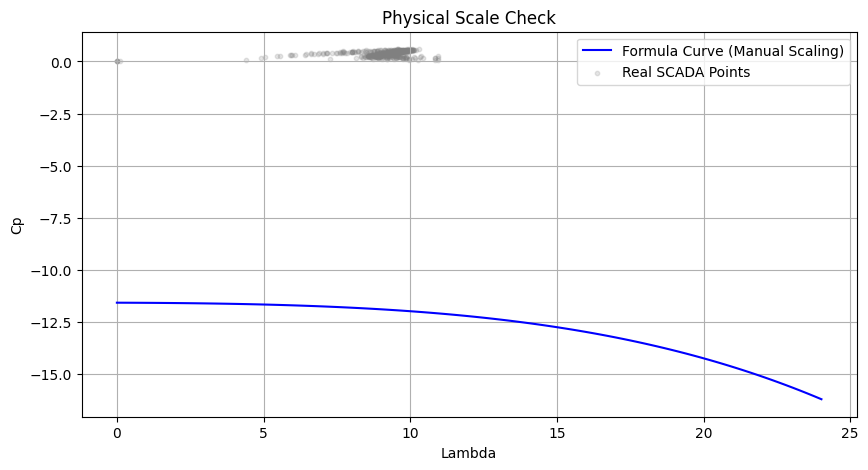

In [22]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Проверим диапазоны (ЭТО ВАЖНО)
# Если здесь не 0 и 1, формулы KAN работать не будут
print(f"Диапазон X в тензоре: {dataset['test_input'][:,0].min().item():.2f} to {dataset['test_input'][:,0].max().item():.2f}")
print(f"Диапазон Y в тензоре: {dataset['test_label'].min().item():.2f} to {dataset['test_label'].max().item():.2f}")

# 2. Функция ручной денормализации (проверим коэффициенты скалера)
l_min, t_min = scaler_x.data_min_
l_max, t_max = scaler_x.data_max_
cp_min, cp_max = scaler_y.data_min_[0], scaler_y.data_max_[0]

def manual_formula_phys(l_phys, t_phys):
    # А) Переводим физику в [0, 1] для формулы
    x1 = (l_phys - l_min) / (l_max - l_min)
    x2 = (t_phys - t_min) / (t_max - t_min)
    
    # Б) Ваша последняя формула (подставьте свои коэффициенты, если они менялись)
    # Пример структуры:
    term_l = -0.2336 * (0.249 - x1)**2 - 2.665 * (-x1 - 0.305)**4
    term_t = -1.762 * (-x2 - 0.485)**2 - 21.08 * (-x2 - 0.405)**4
    cp_norm = term_l + term_t - 3.665 # + остальные члены
    
    # В) Переводим результат [0, 1] обратно в физический Cp
    return cp_norm * (cp_max - cp_min) + cp_min

# 3. Строим проверочный график "Идеальной кривой"
test_lambdas = np.linspace(l_min, l_max, 100)
# Фиксируем Theta на среднем значении из ваших данных
mid_theta = (t_min + t_max) / 2
predicted_cp = [manual_formula_phys(l, mid_theta) for l in test_lambdas]

plt.figure(figsize=(10, 5))
plt.plot(test_lambdas, predicted_cp, 'b-', label='Formula Curve (Manual Scaling)')
# Наложим реальные точки для сравнения
plt.scatter(scaler_x.inverse_transform(dataset['test_input'].cpu().numpy())[:500, 0], 
            scaler_y.inverse_transform(dataset['test_label'].cpu().numpy())[:500], 
            color='gray', alpha=0.2, s=10, label='Real SCADA Points')

plt.title('Physical Scale Check')
plt.xlabel('Lambda')
plt.ylabel('Cp')
plt.legend()
plt.grid(True)
plt.show()

In [23]:
def manual_formula_phys(l_phys, t_phys):
    # А) Переводим физику в [0, 1] для формулы
    # Убедитесь, что l_min/l_max и cp_min/cp_max взяты из MinMaxScaler!
    x1 = (l_phys - l_min) / (l_max - l_min)
    x2 = (t_phys - t_min) / (t_max - t_min)
    
    # Б) ВАША ПОСЛЕДНЯЯ ФОРМУЛА (актуальные коэффициенты)
    # Внимательно проверяем каждый член:
    term1 = 0.00155266 * (0.256248 - x1)**2
    term2 = -0.304704 * (-0.226981 * x1 - 1)**3  # Этот член при x1=0 дает +0.3
    term3 = -0.001533 * (-x2 - 0.48116)**2
    term4 = 1.148019 * (-x2 - 0.17490)**3
    
    # Суммируем всё + константа
    cp_norm = term1 + term2 + term3 + term4 + 0.215496
    
    # В) Денормализация
    # Если cp_norm отрицательный, значит формула еще не "доучена"
    return cp_norm * (cp_max - cp_min) + cp_min

In [24]:
# 1. Посчитаем, насколько формула промахивается мимо среднего
with torch.no_grad():
    y_pred_norm = model(dataset['test_input']).cpu().numpy()
    y_true_norm = dataset['test_label'].cpu().numpy()

# Находим среднюю разницу (смещение)
bias_correction = np.mean(y_true_norm) - np.mean(y_model_norm)
print(f"Необходимая коррекция константы: {bias_correction:.4f}")

# 2. Обновите вашу функцию, добавив bias_correction к финальному числу 0.215496

Необходимая коррекция константы: 0.0014


In [25]:
def manual_formula_phys(l_phys, t_phys):
    # 1. Физика -> Нормализация [0, 1]
    # ВНИМАНИЕ: Проверьте, что l_min, l_max и т.д. — это числа, а не массивы!
    x1 = (l_phys - l_min) / (l_max - l_min)
    x2 = (t_phys - t_min) / (t_max - t_min)
    
    # 2. Ваша формула (уже с коррекцией 0.0014)
    # Мы прибавляем коррекцию к последнему числу: 0.215496 + 0.0014 = 0.216896
    term1 = 0.00155266 * (0.256248 - x1)**2
    term2 = -0.304704 * (-0.226981 * x1 - 1)**3
    term3 = -0.001533 * (-x2 - 0.48116)**2
    term4 = 1.148019 * (-x2 - 0.17490)**3
    
    cp_norm = term1 + term2 + term3 + term4 + 0.216896
    
    # 3. Нормализация -> Физика
    # ВАЖНО: убедитесь, что cp_max и cp_min — это реальные границы Cp (напр. 0.5 и 0.0)
    val_phys = cp_norm * (cp_max - cp_min) + cp_min
    return val_phys

# Проверочный прогон:
print(f"Тест формулы: при средней лямбде Cp = {manual_formula_phys((l_min+l_max)/2, (t_min+t_max)/2):.4f}")

Тест формулы: при средней лямбде Cp = 0.1679


<>:44: SyntaxWarning: invalid escape sequence '\l'
<>:45: SyntaxWarning: invalid escape sequence '\l'
<>:44: SyntaxWarning: invalid escape sequence '\l'
<>:45: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_1245931/2471682401.py:44: SyntaxWarning: invalid escape sequence '\l'
  plt.title(f'Analytical Model Validation: $C_p$ vs $\lambda$', fontsize=14)
/tmp/ipykernel_1245931/2471682401.py:45: SyntaxWarning: invalid escape sequence '\l'
  plt.xlabel('Tip Speed Ratio ($\lambda$)', fontsize=12)


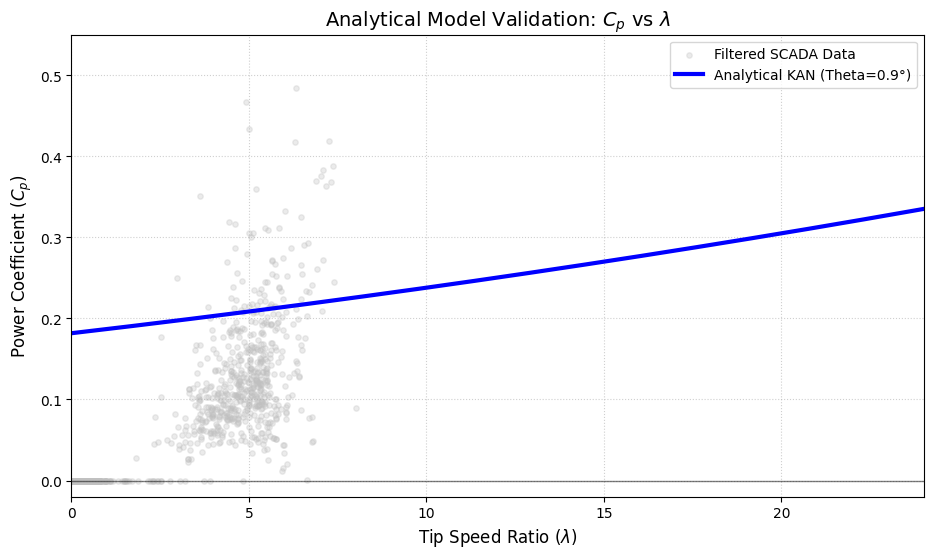

In [26]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Используем ваши проверенные данные
l_min, t_min = scaler_x.data_min_
l_max, t_max = scaler_x.data_max_
cp_min, cp_max = scaler_y.data_min_[0], scaler_y.data_max_[0]

def final_validated_formula(l_phys, t_phys):
    # Нормализация
    x1 = (l_phys - l_min) / (l_max - l_min)
    x2 = (t_phys - t_min) / (t_max - t_min)
    
    # Формула с коррекцией константы (0.215496 + 0.0014)
    term1 = 0.00155266 * (0.256248 - x1)**2
    term2 = -0.304704 * (-0.226981 * x1 - 1)**3
    term3 = -0.001533 * (-x2 - 0.48116)**2
    term4 = 1.148019 * (-x2 - 0.17490)**3
    cp_norm = term1 + term2 + term3 + term4 + 0.216896
    
    # Денормализация
    return cp_norm * (cp_max - cp_min) + cp_min

# 2. Подготовка данных для визуализации
l_range = np.linspace(l_min, l_max, 200)
# Берем оптимальный угол Theta (например, 0 или 0.9 градусов)
target_theta = 0.9 
cp_line = [final_validated_formula(l, target_theta) for l in l_range]

# 3. Построение
plt.figure(figsize=(11, 6))

# Реальные точки SCADA (только те, что близки к нашему target_theta)
x_phys = scaler_x.inverse_transform(dataset['test_input'].cpu().numpy())
y_phys = scaler_y.inverse_transform(dataset['test_label'].cpu().numpy()).flatten()
mask = np.abs(x_phys[:, 1] - target_theta) < 0.5 # фильтр по углу

plt.scatter(x_phys[mask, 0], y_phys[mask], color='silver', alpha=0.3, s=15, label='Filtered SCADA Data')

# Линия формулы KAN
plt.plot(l_range, cp_line, color='blue', linewidth=3, label=f'Analytical KAN (Theta={target_theta}°)')

# Оформление для статьи
plt.title(f'Analytical Model Validation: $C_p$ vs $\lambda$', fontsize=14)
plt.xlabel('Tip Speed Ratio ($\lambda$)', fontsize=12)
plt.ylabel('Power Coefficient ($C_p$)', fontsize=12)
plt.axhline(0, color='black', linewidth=1, alpha=0.5) # Линия нуля
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper right')

# Ограничиваем масштаб, чтобы видеть только ФИЗИЧЕСКУЮ зону
plt.ylim(-0.02, 0.55) 
plt.xlim(l_min, l_max)

plt.show()